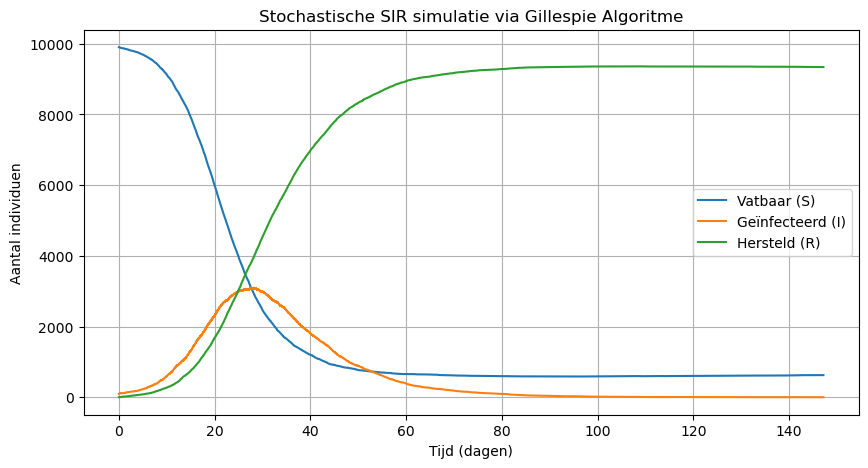

In [ ]:
# Implement Gillespies algorithm

import numpy as np
import matplotlib.pyplot as plt

# Stochastic Model

def gillespie_sir(N, beta, gamma, mu, X0, Y0, Z0, t_max):
    # Initiële waarden
    t = 0.0
    X, Y, Z = X0, Y0, Z0
    
    # Lijsten voor de resultaten
    times = [t]
    X_history = [X]
    Y_history = [Y]
    Z_history = [Z]
    
    while t < t_max and Y > 0:
        # Bereken de rates (propensities) van elke gebeurtenis
        r1 = mu * N                  # Geboorte (X -> X + 1)
        r2 = beta * X * Y / N        # Infectie (X -> X-1, Y -> Y+1)
        r3 = gamma * Y               # Herstel (Y -> Y-1, Z -> Z+1)
        r4 = mu * X                  # Sterfte S (X -> X - 1)
        r5 = mu * Y                  # Sterfte I (Y -> Y - 1)
        r6 = mu * Z                  # Sterfte R (Z -> Z - 1)
        
        rates = [r1, r2, r3, r4, r5, r6]
        R_total = sum(rates)
        
        if R_total == 0:
            break
            
        # 1. Bepaal de tijd tot de volgende gebeurtenis (Exponentiële verdeling)
        u1 = np.random.uniform(0, 1)
        dt = -np.log(u1) / R_total
        t += dt
        
        # 2. Bepaal welke gebeurtenis plaatsvindt
        u2 = np.random.uniform(0, 1)
        probabilities = [r / R_total for r in rates]
        event = np.random.choice(6, p=probabilities)
        
        # 3. Voer de gekozen gebeurtenis uit
        if event == 0:    # Geboorte
            X += 1
        elif event == 1:  # Infectie
            X -= 1
            Y += 1
        elif event == 2:  # Herstel
            Y -= 1
            Z += 1
        elif event == 3:  # Sterfte X
            X -= 1
        elif event == 4:  # Sterfte Y
            Y -= 1
        elif event == 5:  # Sterfte Z
            Z -= 1
            
        # Bewaar de toestand
        times.append(t)
        X_history.append(X)
        Y_history.append(Y)
        Z_history.append(Z)
        
    return np.array(times), np.array(X_history), np.array(Y_history), np.array(Z_history)

# Voorbeeld van een simulatie run:
N = 10000
R0 = 3.0
gamma = 1/10  
beta = R0 * gamma
mu = 0.0001   

X0, Y0, Z0 = 9900, 100, 0
t_max = 365

times, X, Y, Z = gillespie_sir(N, beta, gamma, mu, X0, Y0, Z0, t_max)

# Plotten
plt.figure(figsize=(10, 5))
plt.plot(times, X, label='Vatbaar (S)')
plt.plot(times, Y, label='Geïnfecteerd (I)')
plt.plot(times, Z, label='Hersteld (R)')
plt.xlabel('Tijd (dagen)')
plt.ylabel('Aantal individuen')
plt.title('Stochastische SIR simulatie via Gillespie Algoritme')
plt.legend()
plt.grid(True)
plt.show()

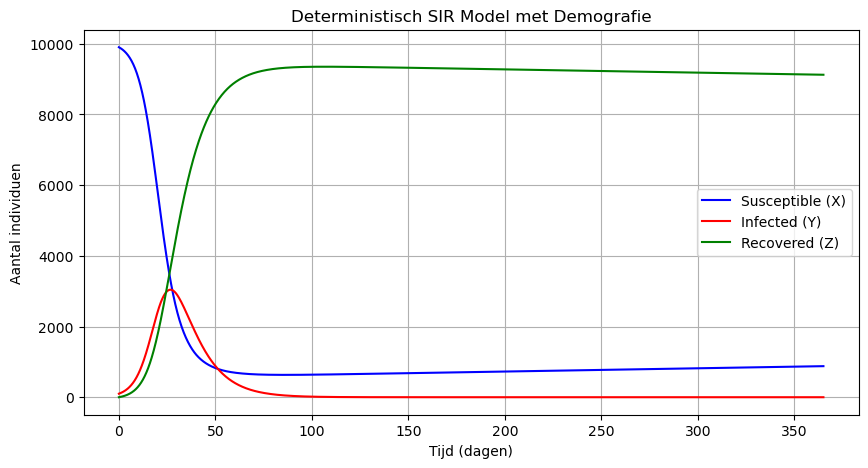

In [ ]:
# Deterministic Model

from scipy.integrate import solve_ivp

def sir_deterministic(t, y, N, beta, gamma, mu):
    X, Y, Z = y
    
    # Differential equations for absolute numbers X, Y, Z
    dX_dt = mu * N - (beta * X * Y / N) - mu * X
    dY_dt = (beta * X * Y / N) - gamma * Y - mu * Y
    dZ_dt = gamma * Y - mu * Z
    
    return [dX_dt, dY_dt, dZ_dt]

# Model parameters
N = 10000        
beta = 0.3      
gamma = 0.1     
mu = 0.0001      

# Initiële aantallen (X0 + Y0 + Z0 = N)
X0 = 9900
Y0 = 100
Z0 = 0
y0 = [X0, Y0, Z0]

# Tijdsdomein
t_span = (0, 365)
t_eval = np.linspace(t_span[0], t_span[1], 2000)

# Oplossen van de ODE
solution = solve_ivp(
    sir_deterministic, 
    t_span, 
    y0, 
    args=(N, beta, gamma, mu), 
    t_eval=t_eval
)

# Plotten
plt.figure(figsize=(10, 5))
plt.plot(solution.t, solution.y[0], label='Susceptible (X)', color='blue')
plt.plot(solution.t, solution.y[1], label='Infected (Y)', color='red')
plt.plot(solution.t, solution.y[2], label='Recovered (Z)', color='green')
plt.title('Deterministisch SIR Model met Demografie')
plt.xlabel('Tijd (dagen)')
plt.ylabel('Aantal individuen')
plt.legend()
plt.grid(True)
plt.show()

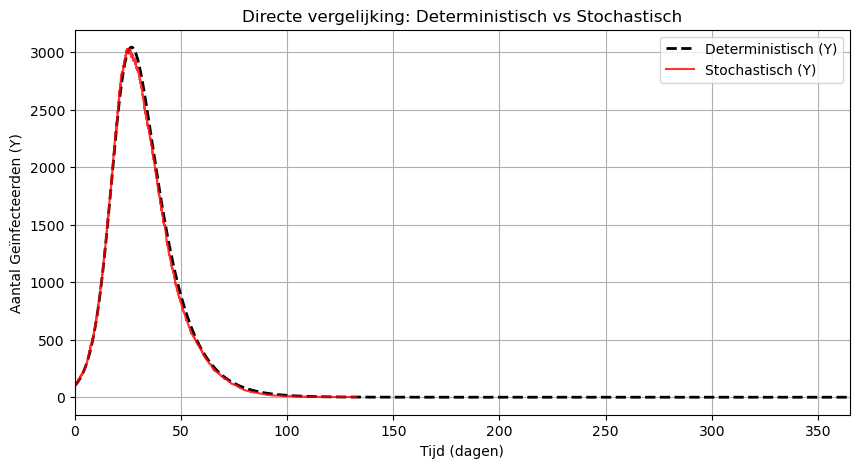

In [ ]:
# De 2 modellen samen plotten

# Parameters die exact gelijk zijn voor beide modellen:
N = 10000
beta = 0.3
gamma = 0.1
mu = 0.0001

X0, Y0, Z0 = 9900, 100, 0
t_max = 365  

# 1. Deterministische oplossing
t_eval = np.linspace(0, t_max, 1000)
sol = solve_ivp(sir_deterministic, (0, t_max), [X0, Y0, Z0], args=(N, beta, gamma, mu), t_eval=t_eval)

# 2. Stochastische oplossing (Gillespie)
t_gillespie, X_g, Y_g, Z_g = gillespie_sir(N, beta, gamma, mu, X0, Y0, Z0, t_max)

# 3. Plotten in één figuur
plt.figure(figsize=(10, 5))

# Deterministisch
plt.plot(sol.t, sol.y[1], color='black', linewidth=2, linestyle='--', label='Deterministisch (Y)')

# Stochastisch
plt.plot(t_gillespie, Y_g, color='red', alpha=0.8, label='Stochastisch (Y)')

plt.xlim(0, t_max)
plt.xlabel('Tijd (dagen)')
plt.ylabel('Aantal Geïnfecteerden (Y)')
plt.title('Directe vergelijking: Deterministisch vs Stochastisch')
plt.legend()
plt.grid(True)
plt.show()

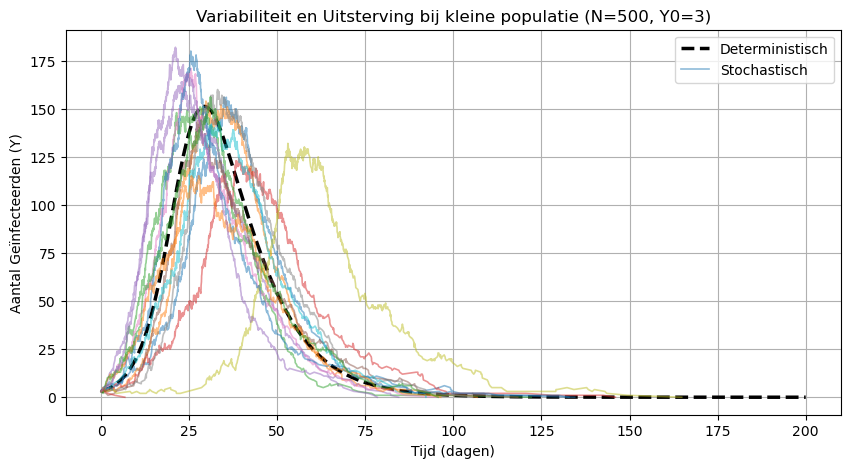

In [ ]:
# Simulatie met kleinere populatie N
N = 500
beta = 0.3
gamma = 0.1
mu = 0.0001
X0, Y0, Z0 = 497, 3, 0  
t_max = 200

# Plot deterministisch
t_eval = np.linspace(0, t_max, 1000)
sol = solve_ivp(sir_deterministic, (0, t_max), [X0, Y0, Z0], args=(N, beta, gamma, mu), t_eval=t_eval)

plt.figure(figsize=(10, 5))
plt.plot(sol.t, sol.y[1], color='black', linewidth=2.5, linestyle='--', label='Deterministisch')

# Plot meerdere stochastische runs
for i in range(15):
    t_gillespie, X_g, Y_g, Z_g = gillespie_sir(N, beta, gamma, mu, X0, Y0, Z0, t_max)
    plt.plot(t_gillespie, Y_g, alpha=0.5, linewidth=1.2, label='Stochastisch' if i == 0 else "")

plt.xlabel('Tijd (dagen)')
plt.ylabel('Aantal Geïnfecteerden (Y)')
plt.title('Variabiliteit en Uitsterving bij kleine populatie (N=500, Y0=3)')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
# Investigate Simulation Variability and Negative Co-variance

import numpy as np

def run_multiple_gillespie(N, beta, gamma, mu, X0, Y0, Z0, t_max, n_runs=100, num_points=500):
    """
    Voert meerdere Gillespie SIR-simulaties uit en interpoleert de resultaten
    naar een vast tijdsrooster om gemiddelden, varianties en covarianties te berekenen.
    """
    # 1. Maak een vast tijdsrooster aan
    t_grid = np.linspace(0, t_max, num_points)
    
    # Matrices om de geïnterpoleerde runs op te slaan (vorm: n_runs x num_points)
    S_matrix = np.zeros((n_runs, num_points))
    I_matrix = np.zeros((n_runs, num_points))
    R_matrix = np.zeros((n_runs, num_points))
    
    # 2. Voer de simulaties uit
    for i in range(n_runs):
        t_sim, S_sim, I_sim, R_sim = gillespie_sir(N, beta, gamma, mu, X0, Y0, Z0, t_max)
        
        # Als de ziekte vroegtijdig uitsterft, vul de resterende tijd aan tot t_max
        if t_sim[-1] < t_max:
            t_sim = np.append(t_sim, t_max)
            S_sim = np.append(S_sim, S_sim[-1])
            I_sim = np.append(I_sim, I_sim[-1])
            R_sim = np.append(R_sim, R_sim[-1])
            
        # Interpoleer de resultaten op het vaste tijdsrooster
        S_matrix[i, :] = np.interp(t_grid, t_sim, S_sim)
        I_matrix[i, :] = np.interp(t_grid, t_sim, I_sim)
        R_matrix[i, :] = np.interp(t_grid, t_sim, R_sim)
        
    # 3. Bereken Statistieken per tijdstip (over de kolommen/axis=0)
    S_mean = np.mean(S_matrix, axis=0)
    I_mean = np.mean(I_matrix, axis=0)
    
    I_var = np.var(I_matrix, axis=0)
    I_std = np.std(I_matrix, axis=0)
    
    # Covariantie tussen S en I per tijdstip berekenen
    cov_SI = np.zeros(num_points)
    for k in range(num_points):
        # np.cov geeft een 2x2 matrix: [[Var(S), Cov(S,I)], [Cov(I,S), Var(I)]]
        cov_matrix = np.cov(S_matrix[:, k], I_matrix[:, k])
        cov_SI[k] = cov_matrix[0, 1]
        
    # Return alle berekende data in een dictionary
    return {
        't_grid': t_grid,
        'S_matrix': S_matrix,
        'I_matrix': I_matrix,
        'S_mean': S_mean,
        'I_mean': I_mean,
        'I_var': I_var,
        'I_std': I_std,
        'cov_SI': cov_SI
    }

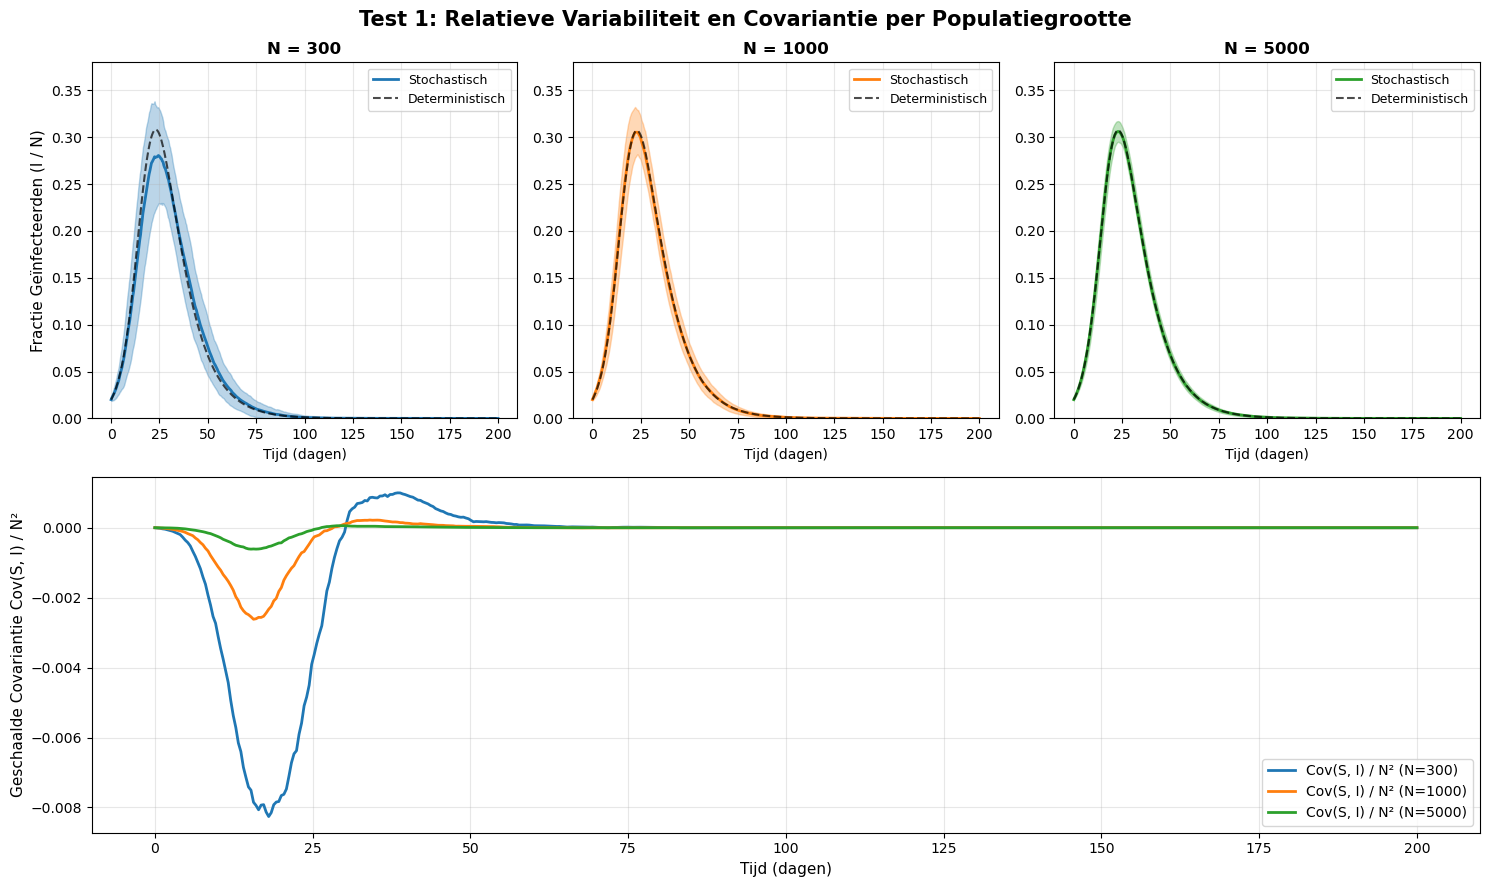

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- Parameters & Setup ---
beta = 0.3
gamma = 0.1
mu = 0.0001
t_max = 200
n_runs = 100

pop_sizes = [300, 1000, 5000]
colors = ['tab:blue', 'tab:orange', 'tab:green']

# Maak een grid: bovenste rij heeft 3 plots, onderste rij heeft 1 grote brede plot
fig = plt.figure(figsize=(15, 9))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1])

# Drie subplots bovenin voor de populaties
ax_top = [fig.add_subplot(gs[0, i]) for i in range(3)]

# Één brede subplot onderin voor de covarianties
ax_bottom = fig.add_subplot(gs[1, :])

# Fixeer de Y-as bovenin zodat ze direct vergelijkbaar zijn
for ax in ax_top:
    ax.set_ylim(0, 0.38)
    ax.set_xlabel('Tijd (dagen)', fontsize=10)
    ax.grid(True, alpha=0.3)

ax_top[0].set_ylabel('Fractie Geïnfecteerden (I / N)', fontsize=11)

# --- Lus over de Populatiegroottes ---
for i, (N, color) in enumerate(zip(pop_sizes, colors)):
    Y0 = int(0.02 * N)
    X0 = N - Y0
    Z0 = 0
    
    # Deterministisch model
    t_eval = np.linspace(0, t_max, 500)
    sol = solve_ivp(sir_deterministic, (0, t_max), [X0, Y0, Z0], args=(N, beta, gamma, mu), t_eval=t_eval)
    
    # Stochastische runs
    results = run_multiple_gillespie(N, beta, gamma, mu, X0, Y0, Z0, t_max, n_runs=n_runs)
    
    t_grid = results['t_grid']
    I_mean = results['I_mean']
    I_std = results['I_std']
    cov_SI = results['cov_SI']
    
    # 1. Bovenste rijen: Per N een eigen subplot
    ax = ax_top[i]
    ax.plot(t_grid, I_mean / N, color=color, linewidth=2, label=f'Stochastisch')
    ax.plot(sol.t, sol.y[1] / N, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Deterministisch')
    
    # Schaduwband voor variabiliteit
    lower_bound = np.maximum(0, (I_mean - I_std) / N)
    upper_bound = (I_mean + I_std) / N
    ax.fill_between(t_grid, lower_bound, upper_bound, color=color, alpha=0.3)
    
    ax.set_title(f'N = {N}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    
    # 2. Onderste rij: Alle covarianties samen in één brede plot
    ax_bottom.plot(t_grid, cov_SI / (N**2), color=color, linewidth=2, label=f'Cov(S, I) / N² (N={N})')

# Opmaak onderste plot
ax_bottom.set_xlabel('Tijd (dagen)', fontsize=11)
ax_bottom.set_ylabel('Geschaalde Covariantie Cov(S, I) / N²', fontsize=11)
ax_bottom.legend(loc='lower right', fontsize=10)
ax_bottom.grid(True, alpha=0.3)

fig.suptitle('Test 1: Relatieve Variabiliteit en Covariantie per Populatiegrootte', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


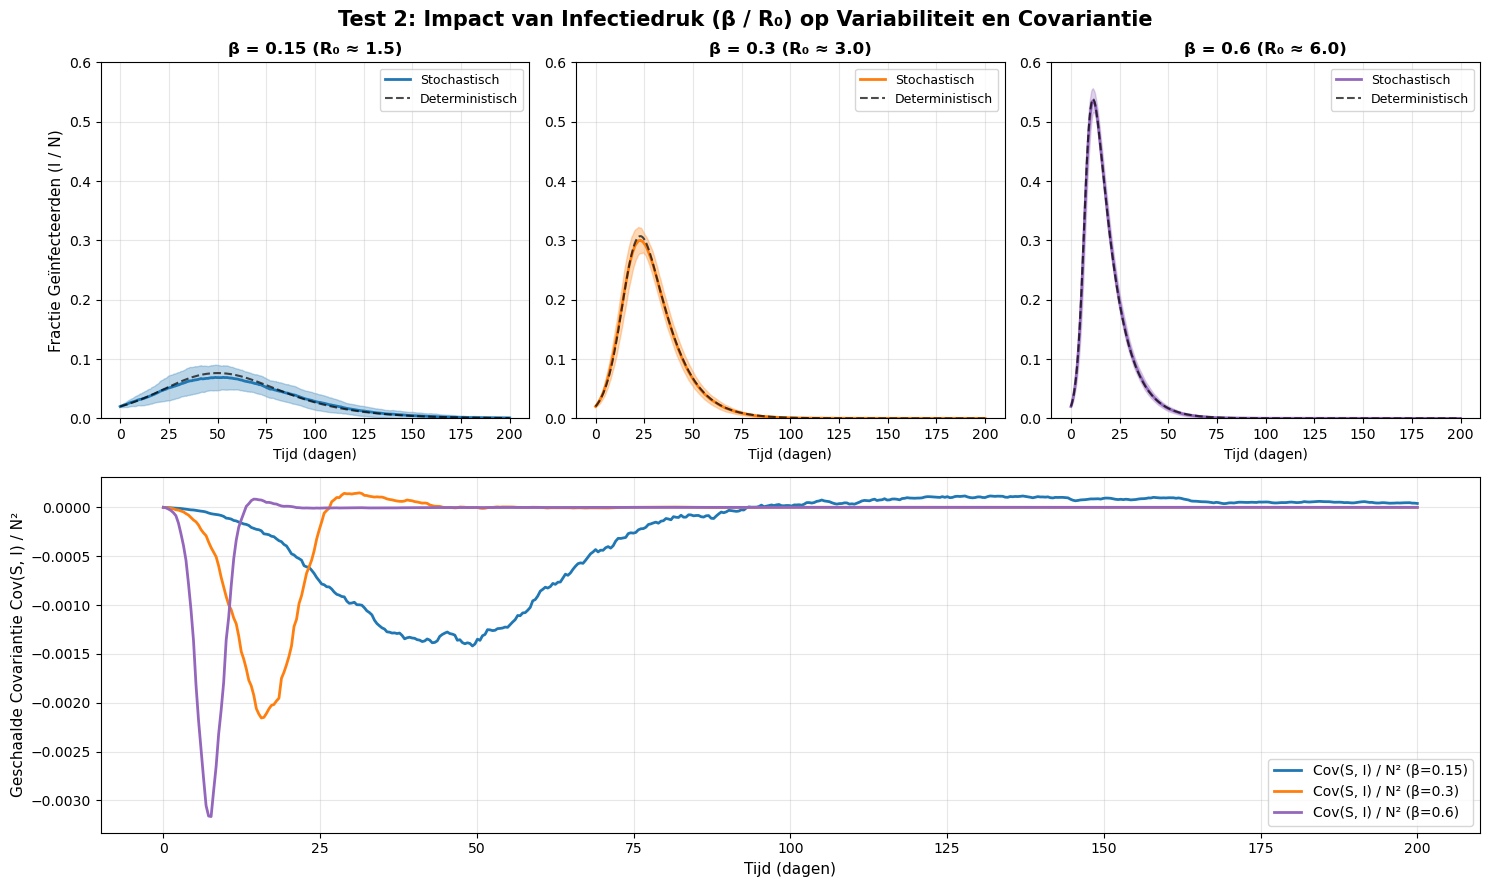

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- Parameters & Setup ---
N = 1000
Y0 = 20
X0 = N - Y0
Z0 = 0

gamma = 0.1
mu = 0.0001
t_max = 200
n_runs = 100

# Drie verschillende waarden voor beta (en R0)
beta_values = [0.15, 0.30, 0.60]
colors = ['tab:blue', 'tab:orange', 'tab:purple']

# Maak hetzelfde 3+1 grid als bij Test 1
fig = plt.figure(figsize=(15, 9))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1])

ax_top = [fig.add_subplot(gs[0, i]) for i in range(3)]
ax_bottom = fig.add_subplot(gs[1, :])

for ax in ax_top:
    ax.set_ylim(0, 0.60) # Piek kan hoger worden bij hoge beta
    ax.set_xlabel('Tijd (dagen)', fontsize=10)
    ax.grid(True, alpha=0.3)

ax_top[0].set_ylabel('Fractie Geïnfecteerden (I / N)', fontsize=11)

# --- Loop over de Beta-waarden ---
for i, (beta, color) in enumerate(zip(beta_values, colors)):
    R0 = beta / (gamma + mu)
    
    # 1. Deterministisch Model
    t_eval = np.linspace(0, t_max, 500)
    sol = solve_ivp(sir_deterministic, (0, t_max), [X0, Y0, Z0], args=(N, beta, gamma, mu), t_eval=t_eval)
    
    # 2. Stochastische Runs
    results = run_multiple_gillespie(N, beta, gamma, mu, X0, Y0, Z0, t_max, n_runs=n_runs)
    
    t_grid = results['t_grid']
    I_mean = results['I_mean']
    I_std = results['I_std']
    cov_SI = results['cov_SI']
    
    # Bovenste rij: Per beta een eigen subplot
    ax = ax_top[i]
    ax.plot(t_grid, I_mean / N, color=color, linewidth=2, label='Stochastisch')
    ax.plot(sol.t, sol.y[1] / N, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Deterministisch')
    
    # Schaduwband
    lower_bound = np.maximum(0, (I_mean - I_std) / N)
    upper_bound = (I_mean + I_std) / N
    ax.fill_between(t_grid, lower_bound, upper_bound, color=color, alpha=0.3)
    
    ax.set_title(f'β = {beta} (R₀ ≈ {R0:.1f})', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    
    # Onderste rij: Alle covarianties bij elkaar
    ax_bottom.plot(t_grid, cov_SI / (N**2), color=color, linewidth=2, label=f'Cov(S, I) / N² (β={beta})')

# Opmaak onderste plot
ax_bottom.set_xlabel('Tijd (dagen)', fontsize=11)
ax_bottom.set_ylabel('Geschaalde Covariantie Cov(S, I) / N²', fontsize=11)
ax_bottom.legend(loc='lower right', fontsize=10)
ax_bottom.grid(True, alpha=0.3)

fig.suptitle('Test 2: Impact van Infectiedruk (β / R₀) op Variabiliteit en Covariantie', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

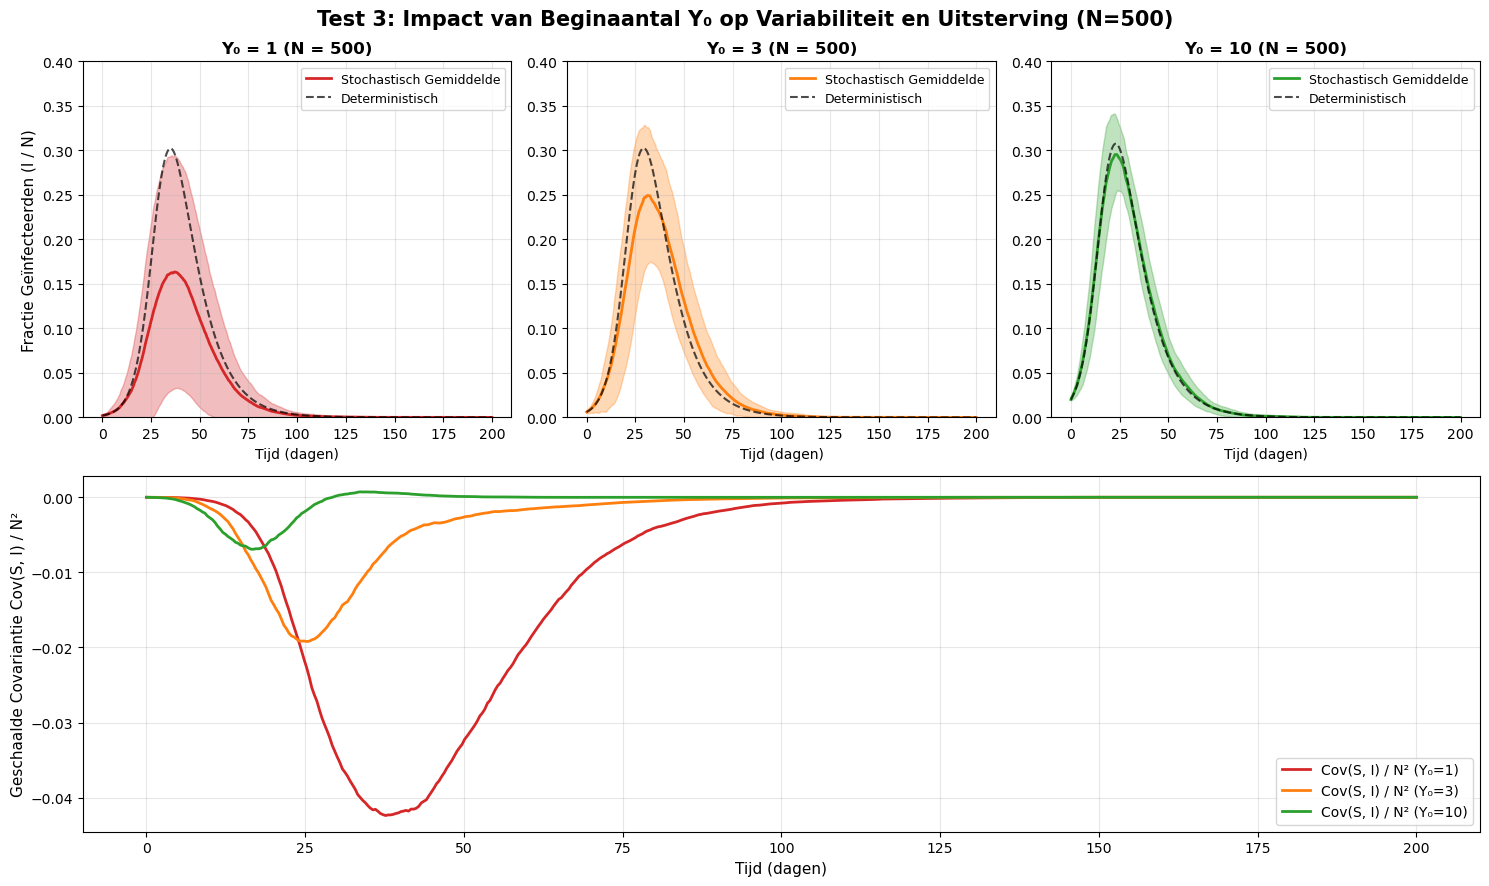

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- Parameters & Setup ---
N = 500
beta = 0.3
gamma = 0.1
mu = 0.0001
t_max = 200
n_runs = 100

y0_values = [1, 3, 10]
colors = ['tab:red', 'tab:orange', 'tab:green']

# Grid: 3 plots bovenin, 1 brede plot onderin
fig = plt.figure(figsize=(15, 9))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1])

ax_top = [fig.add_subplot(gs[0, i]) for i in range(3)]
ax_bottom = fig.add_subplot(gs[1, :])

for ax in ax_top:
    ax.set_ylim(0, 0.40)
    ax.set_xlabel('Tijd (dagen)', fontsize=10)
    ax.grid(True, alpha=0.3)

ax_top[0].set_ylabel('Fractie Geïnfecteerden (I / N)', fontsize=11)

# --- Loop over de Y0-waarden ---
for i, (Y0, color) in enumerate(zip(y0_values, colors)):
    X0 = N - Y0
    Z0 = 0
    
    # 1. Deterministisch Model
    t_eval = np.linspace(0, t_max, 500)
    sol = solve_ivp(sir_deterministic, (0, t_max), [X0, Y0, Z0], args=(N, beta, gamma, mu), t_eval=t_eval)
    
    # 2. Stochastische Runs
    results = run_multiple_gillespie(N, beta, gamma, mu, X0, Y0, Z0, t_max, n_runs=n_runs)
    
    t_grid = results['t_grid']
    I_mean = results['I_mean']
    I_std = results['I_std']
    cov_SI = results['cov_SI']
    
    # Bovenste rij: Per Y0 een eigen subplot
    ax = ax_top[i]
    ax.plot(t_grid, I_mean / N, color=color, linewidth=2, label='Stochastisch Gemiddelde')
    ax.plot(sol.t, sol.y[1] / N, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Deterministisch')
    
    # Schaduwband
    lower_bound = np.maximum(0, (I_mean - I_std) / N)
    upper_bound = (I_mean + I_std) / N
    ax.fill_between(t_grid, lower_bound, upper_bound, color=color, alpha=0.3)
    
    ax.set_title(f'Y₀ = {Y0} (N = {N})', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    
    # Onderste rij: Alle covarianties bij elkaar
    ax_bottom.plot(t_grid, cov_SI / (N**2), color=color, linewidth=2, label=f'Cov(S, I) / N² (Y₀={Y0})')

# Opmaak onderste plot
ax_bottom.set_xlabel('Tijd (dagen)', fontsize=11)
ax_bottom.set_ylabel('Geschaalde Covariantie Cov(S, I) / N²', fontsize=11)
ax_bottom.legend(loc='lower right', fontsize=10)
ax_bottom.grid(True, alpha=0.3)

fig.suptitle('Test 3: Impact van Beginaantal Y₀ op Variabiliteit en Uitsterving (N=500)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [34]:
def extract_summary_stats(results, N):
    I_mean = results['I_mean']
    I_std = results['I_std']
    cov_SI = results['cov_SI']
    I_matrix = results['I_matrix']
    
    # Piekindex en waarden
    peak_idx = np.argmax(I_mean)
    mean_peak_frac = I_mean[peak_idx] / N
    cv_peak = (I_std[peak_idx] / I_mean[peak_idx]) * 100
    
    # Minimale covariantie
    min_scaled_cov = np.min(cov_SI) / (N**2)
    
    # Vroegtijdige uitsterving: runs waarin I op dag 50 gelijk is aan 0
    t_50_idx = int(len(results['t_grid']) * (50 / results['t_grid'][-1]))
    extinction_rate = np.mean(I_matrix[:, t_50_idx] == 0) * 100
    
    return {
        'Piek Fractie': round(mean_peak_frac, 3),
        'CV Piek (%)': round(cv_peak, 1),
        'Min Cov / N²': round(min_scaled_cov, 5),
        'Uitsterving (%)': round(extinction_rate, 1)
    }

In [ ]:
import pandas as pd
import numpy as np

def bereken_test_statistieken(test_naam, parameter_naam, parameter_waarden, run_functie_args_lijst):
    resultaten_lijst = []
    
    for val, args in zip(parameter_waarden, run_functie_args_lijst):
        # Voer simulaties uit
        res = run_multiple_gillespie(**args)
        
        N = args['N']
        I_mean_frac = res['I_mean'] / N
        I_std_frac = res['I_std'] / N
        cov_scaled = res['cov_SI'] / (N**2)
        
        # Zoek de piek van het stochastisch gemiddelde
        peak_idx = np.argmax(I_mean_frac)
        
        mu_peak = I_mean_frac[peak_idx]
        sigma_peak = I_std_frac[peak_idx]
        cv_peak = (sigma_peak / mu_peak) * 100 if mu_peak > 0 else 0
        min_cov = np.min(cov_scaled)
        
        resultaten_lijst.append({
            'Test': test_naam,
            parameter_naam: val,
            'N': N,
            'Gemiddelde Piek (I/N)': f"{mu_peak:.3f}",
            'Std. Dev. Piek (σ)': f"{sigma_peak:.3f}",
            'Relatieve Ruis (CV %)': f"{cv_peak:.1f}%",
            'Min. Cov(S,I)/N²': f"{min_cov:.5f}"
        })
        
    return pd.DataFrame(resultaten_lijst)

# Toon in Jupyter Notebook:
display(df_test1)

# Toon in Jupyter Notebook:
display(df_test2)

# Toon in Jupyter Notebook:
display(df_test3)

# print(df_test1.to_latex(index=False))



,Test,Parameter (N),Det. Piek (I/N),Stoch. Piek (I/N),Ruis op Piek (CV %),Vroegtijdig Uitgestorven,"Min Cov(S,I)/N²"
0,Test 1 (N),300,0.323,0.321,15.2%,0%,-0.00411
1,Test 1 (N),1000,0.307,0.301,9.0%,0%,-0.00363
2,Test 1 (N),5000,0.302,0.297,3.7%,0%,-0.00247


,Test,Parameter (beta),Det. Piek (I/N),Stoch. Piek (I/N),Ruis op Piek (CV %),Vroegtijdig Uitgestorven,"Min Cov(S,I)/N²"
0,Test 2 (Beta),0.15,0.076,0.073,30.1%,1%,-0.00153
1,Test 2 (Beta),0.30,0.307,0.302,8.4%,0%,-0.00291
2,Test 2 (Beta),0.60,0.538,0.536,3.7%,0%,-0.00291


,Test,Parameter (Y0),Det. Piek (I/N),Stoch. Piek (I/N),Ruis op Piek (CV %),Vroegtijdig Uitgestorven,"Min Cov(S,I)/N²"
0,Test 3 (Y0),1,0.302,0.171,74.0%,31%,-0.04036
1,Test 3 (Y0),3,0.302,0.256,34.9%,6%,-0.01957
2,Test 3 (Y0),10,0.307,0.294,12.6%,0%,-0.00713


\begin{tabular}{lrlllll}
\toprule
      Test &  Parameter (N) & Det. Piek (I/N) & Stoch. Piek (I/N) & Ruis op Piek (CV \%) & Vroegtijdig Uitgestorven & Min Cov(S,I)/N² \\
\midrule
Test 1 (N) &            300 &           0.323 &             0.321 &               15.2\% &                       0\% &        -0.00411 \\
Test 1 (N) &           1000 &           0.307 &             0.301 &                9.0\% &                       0\% &        -0.00363 \\
Test 1 (N) &           5000 &           0.302 &             0.297 &                3.7\% &                       0\% &        -0.00247 \\
\bottomrule
\end{tabular}



/var/folders/_k/vwdb1kx10j5g8bw6v8r_bn8m0000gn/T/ipykernel_56103/2480682889.py:45: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(df_test1.to_latex(index=False))
